Jun0425: This file consists of 4 discontinuous 10-minute acquisitions that have been concatenated; one hour elapsed between the start of each acquisition. If you imagine this as a continuous 40-minute file for the sake of simplicity, stims. were applied at minutes 5, 15, 25, and 35; the corresponding time steps would be 122175, 366525, 610875, and 855225. As was true of the Jun0523 file, all of the applied stimuli here were identical except the one at 25 minutes, which was a perturbation stim. The breaks between the four constituent acquisitions occurred at 10, 20, and 30 minutes (244350, 488700, and 733050). One of the rationales for this experiment was to allow the population to (ostensibly) reestablish naivete between trials.

In [1]:
## Import peaks from npy file
import numpy as np
peak_times = np.load('../data/sea_slug/Jun0425_peak_times.npy', allow_pickle=True).item()  # Load as dictionary

In [2]:
def adjust_time(t, sr):
    if t < 244350:
        return t
    elif t < 488700:
        return t + sr * 50 * 60 
    elif t < 733050:
        return t + 2 * (sr * 50 * 60)
    else:
        return t + 3 * (sr * 50 * 60)

In [3]:
sr = 407.25
stimuli = [adjust_time(time, sr) / (sr * 60) for time in [122175, 366525, 610875, 855225]]

In [4]:
stimuli

[5.0, 65.0, 125.0, 185.0]

In [5]:
T = 190
observation_intervals = [[0, 10], [60, 70], [120, 130], [180, 190]]

In [6]:
import matplotlib.pyplot as plt
## Compile with tikz and times font
plt.rc('text', usetex=True)
plt.rc('font', family='times')

In [7]:
import hep

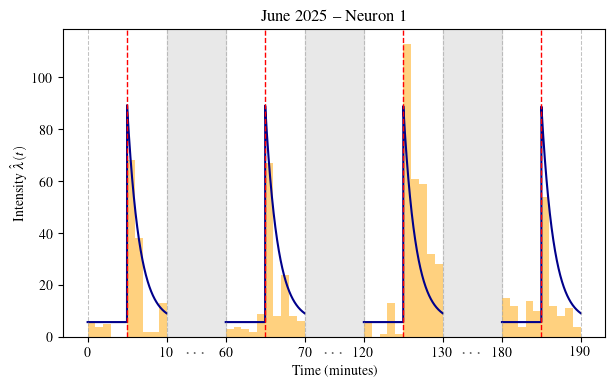

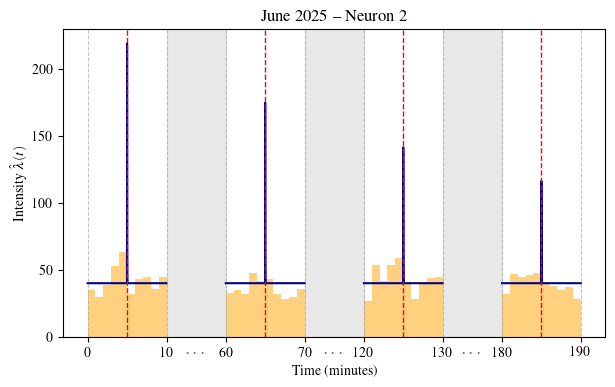

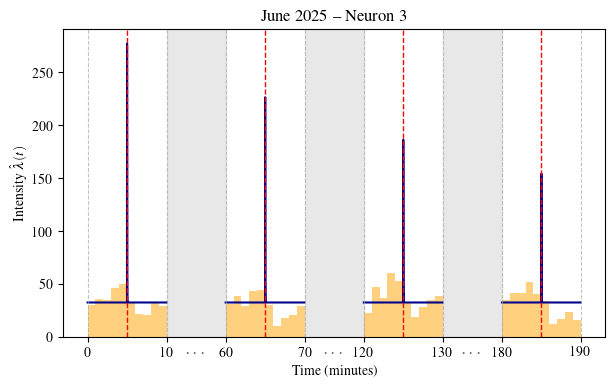

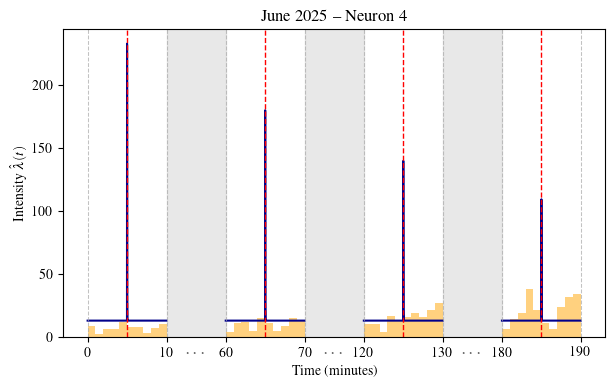

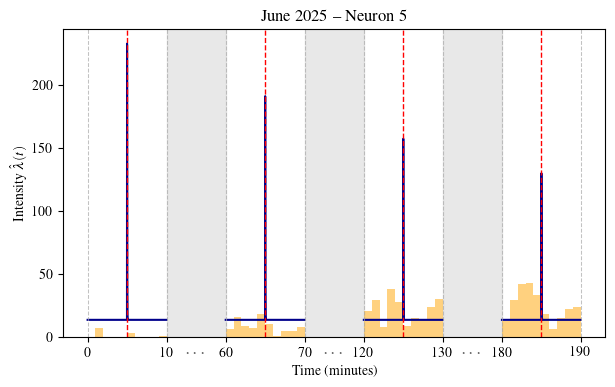

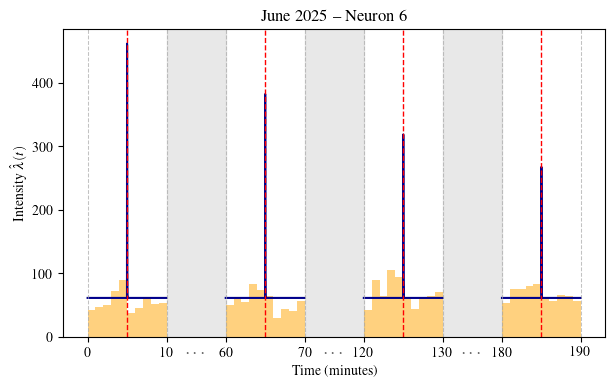

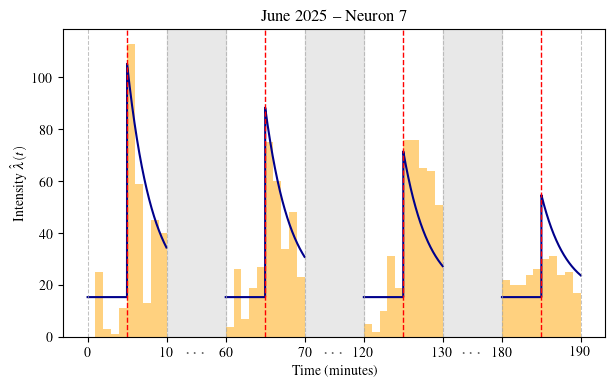

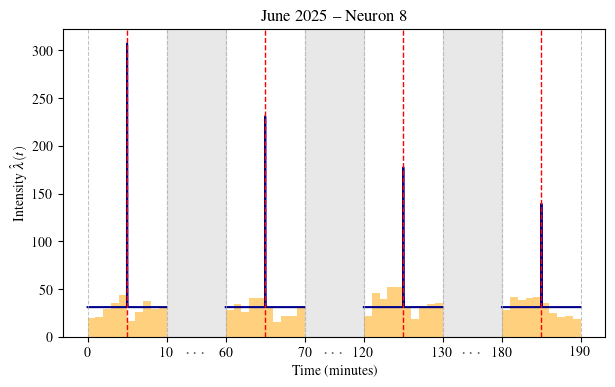

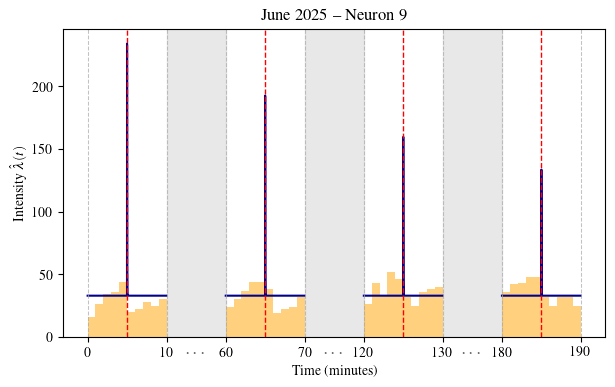

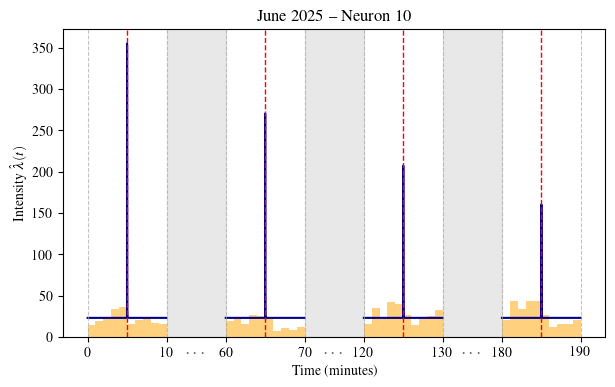

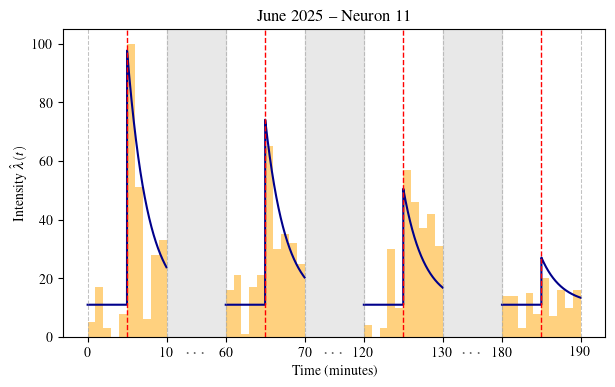

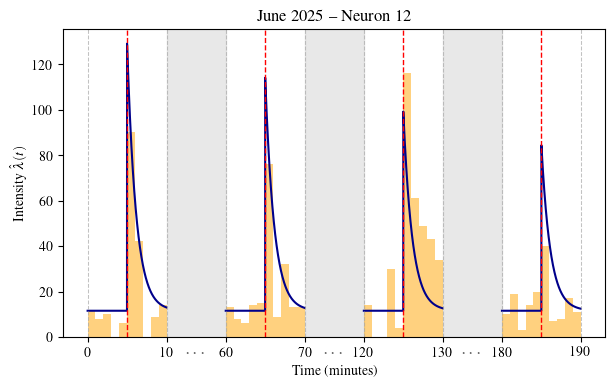

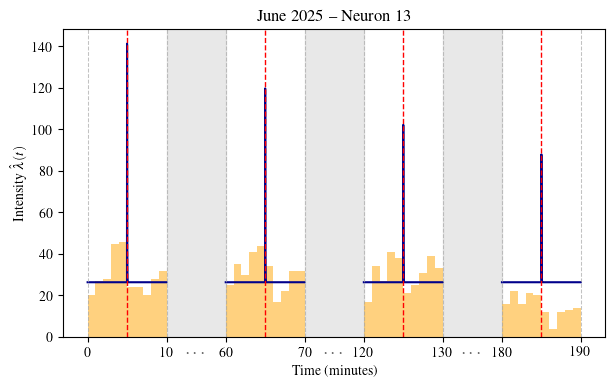

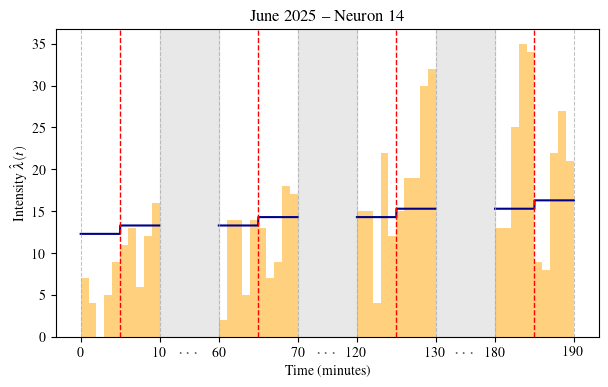

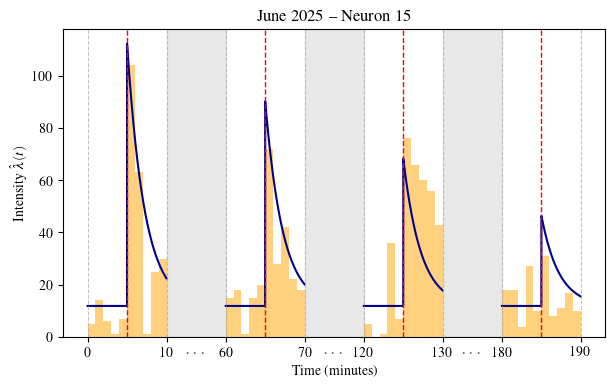

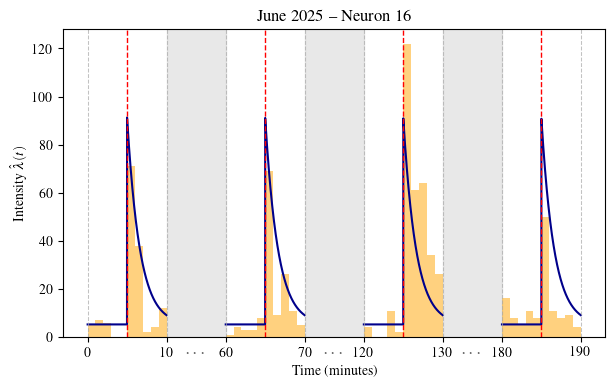

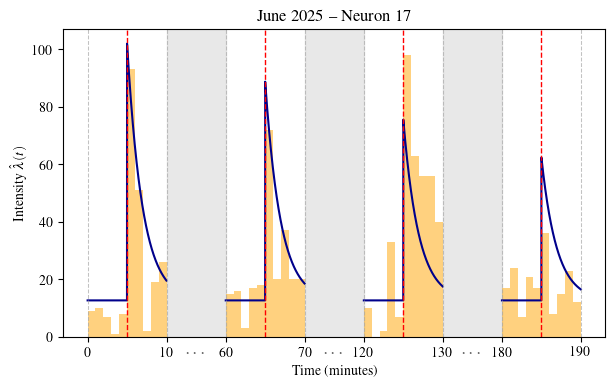

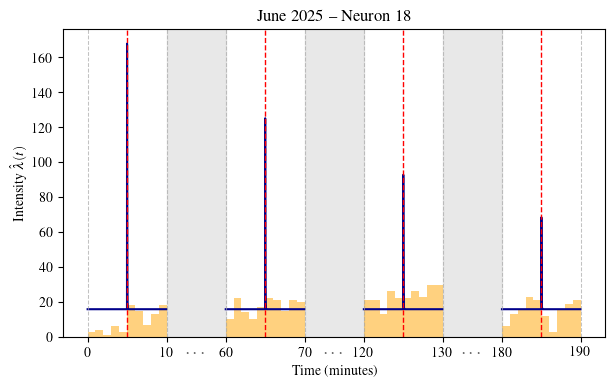

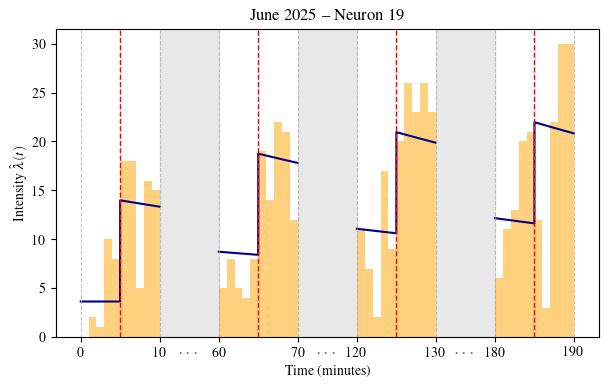

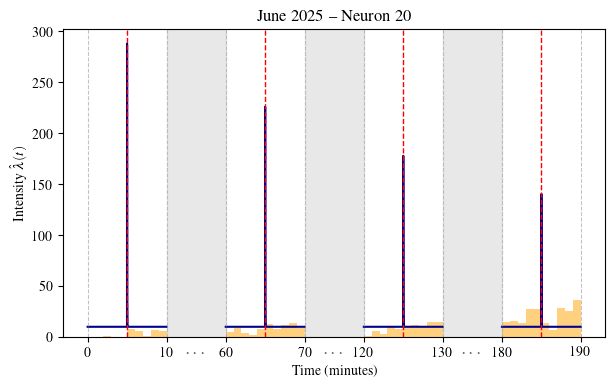

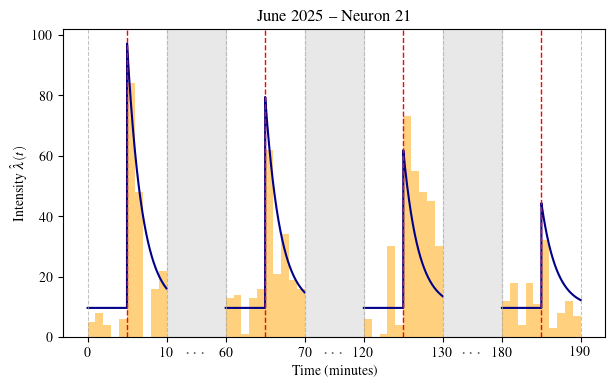

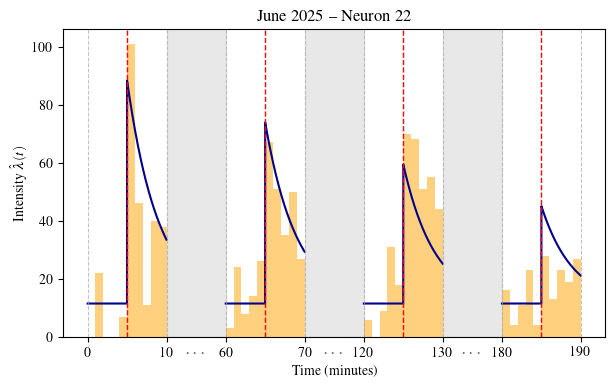

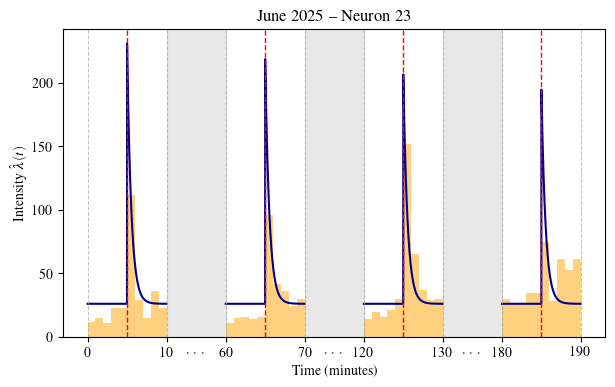

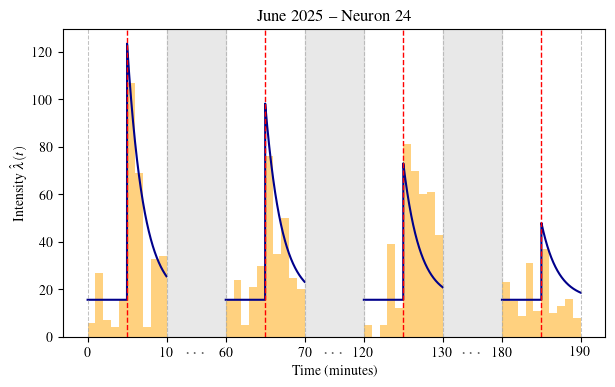

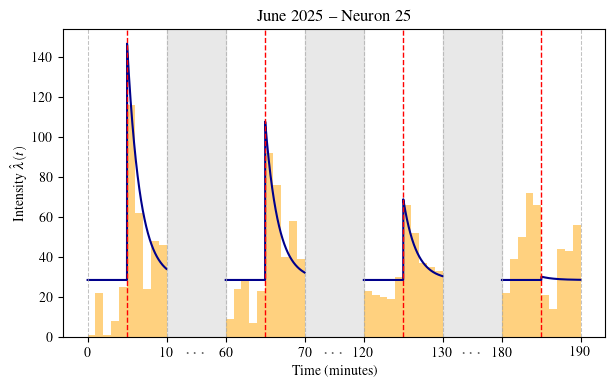

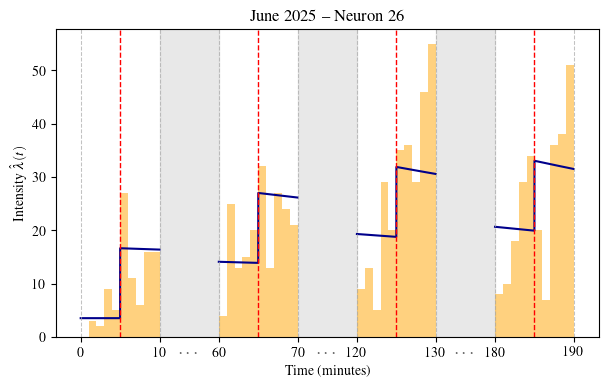

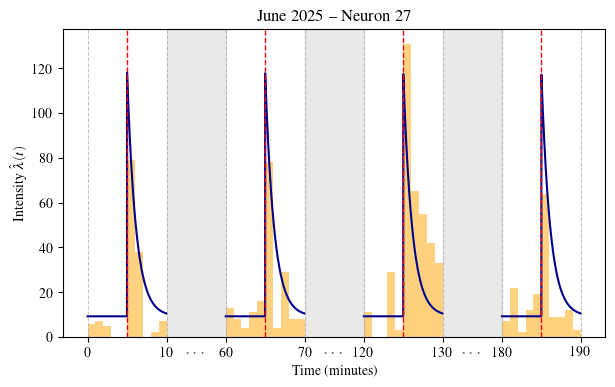

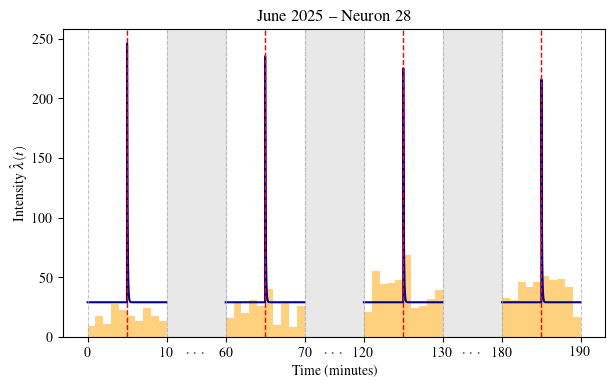

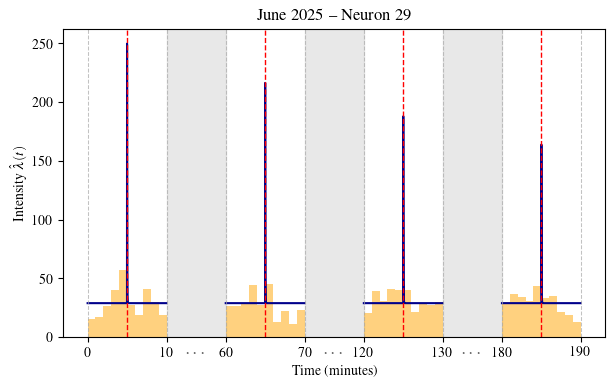

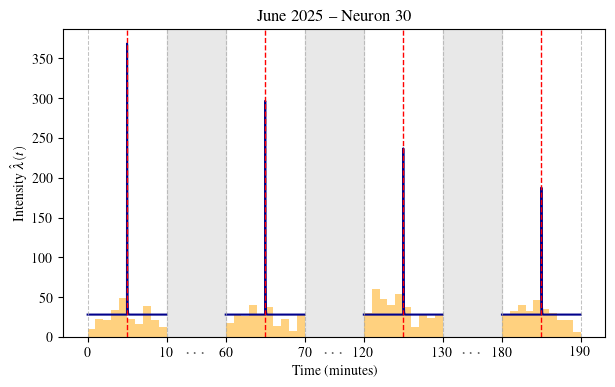

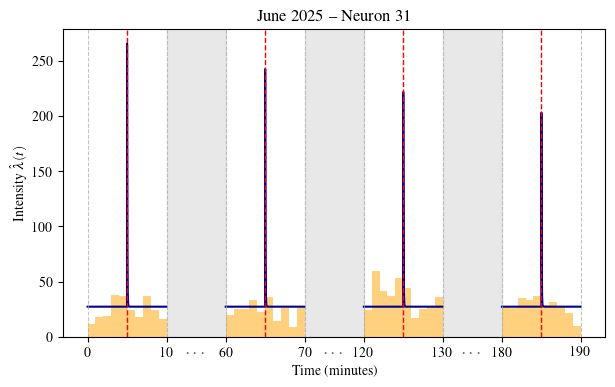

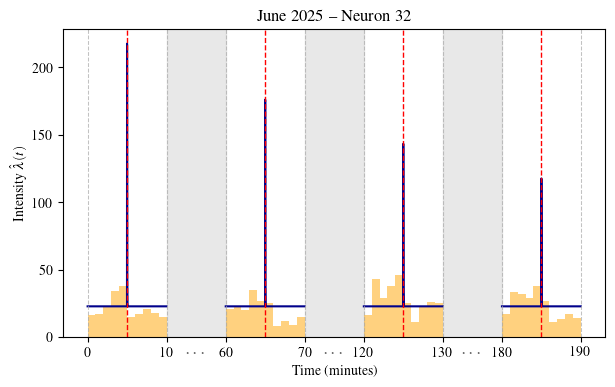

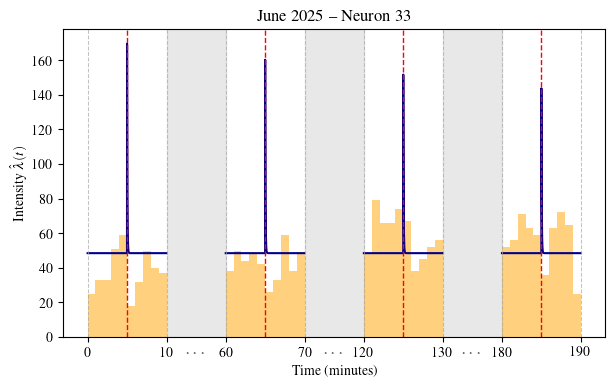

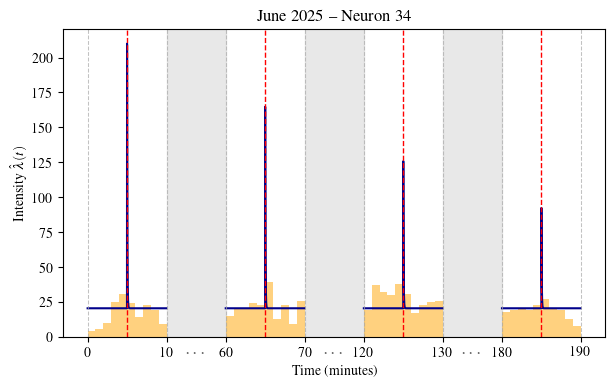

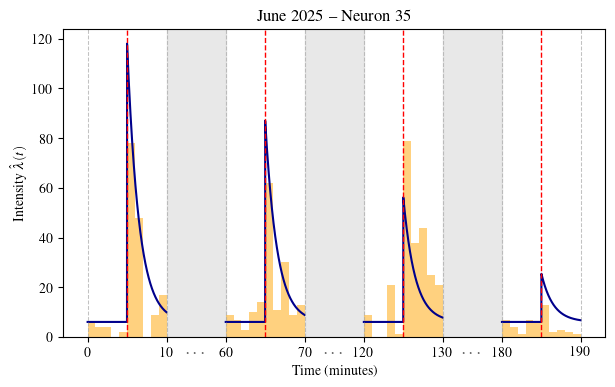

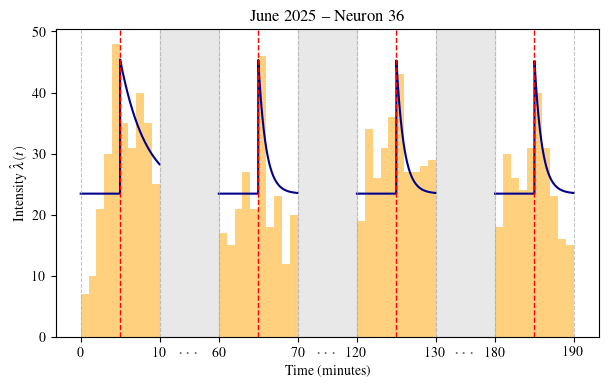

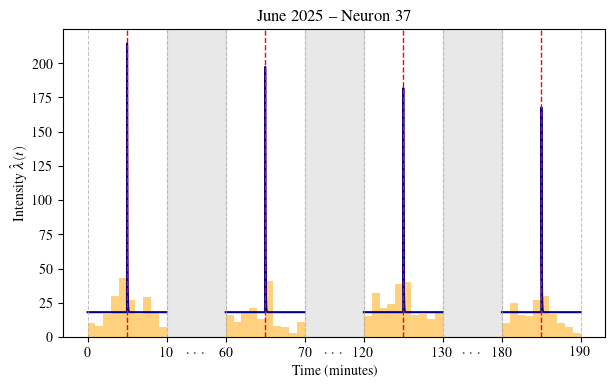

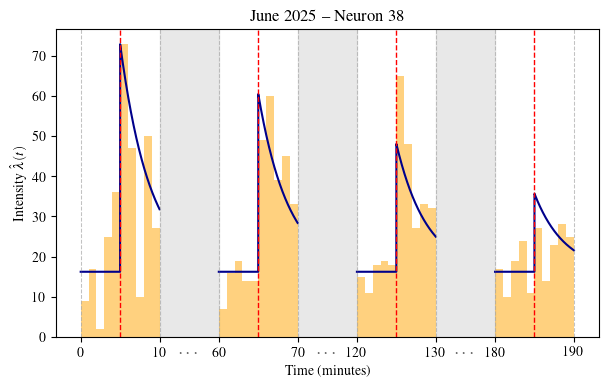

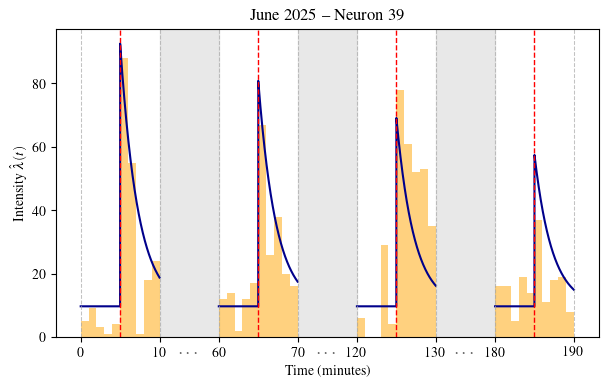

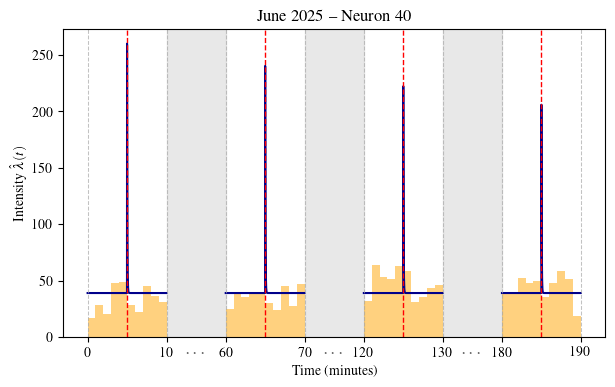

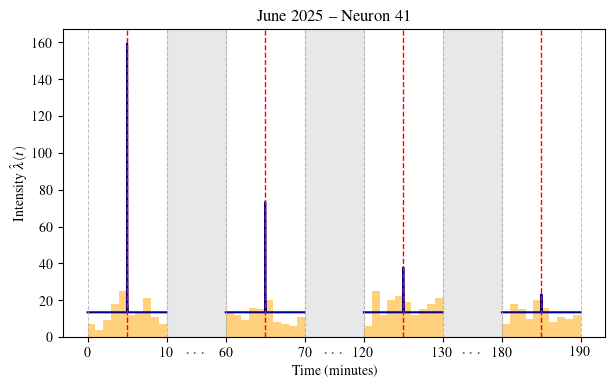

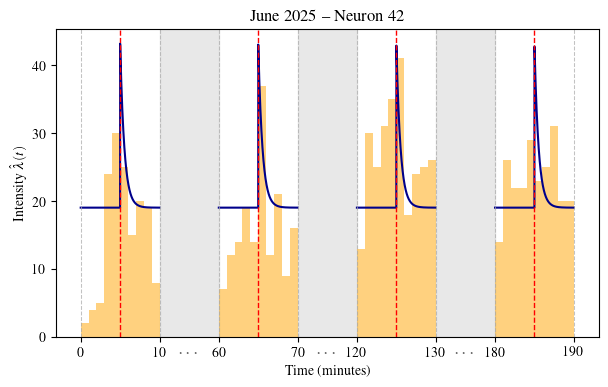

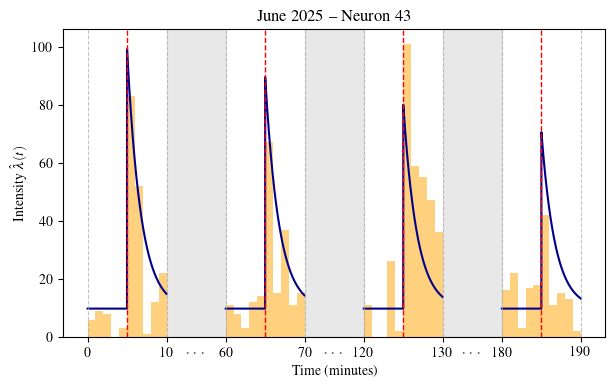

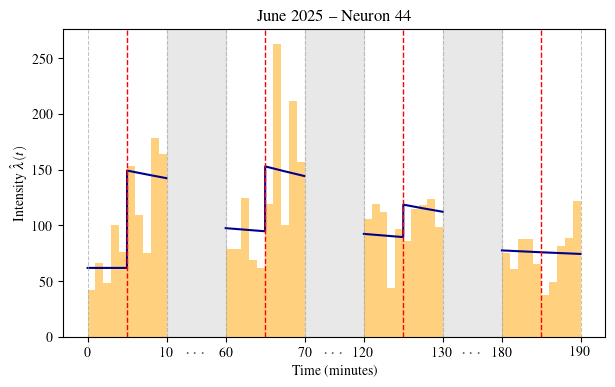

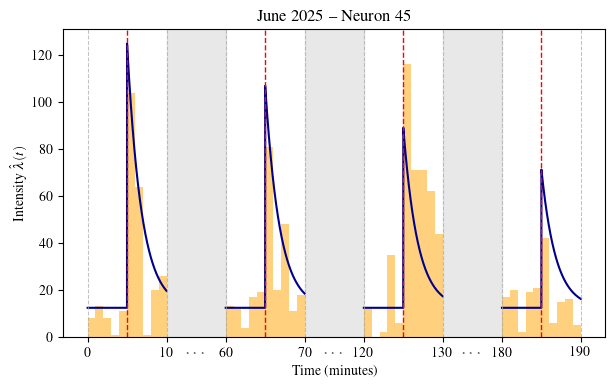

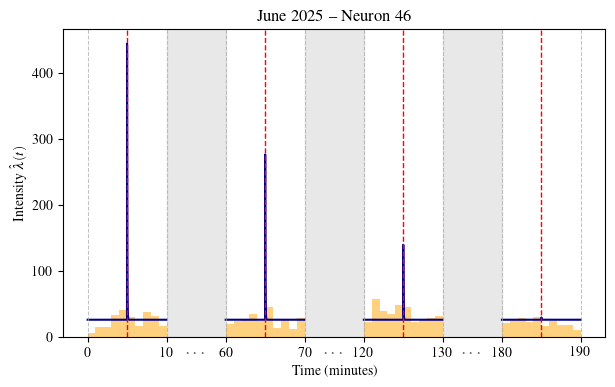

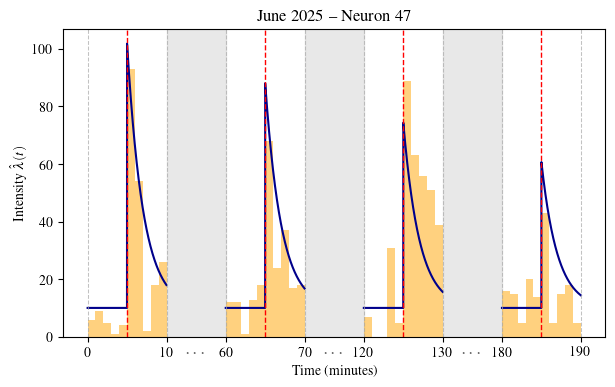

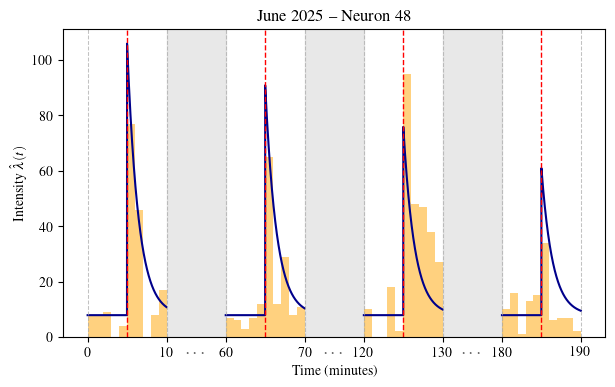

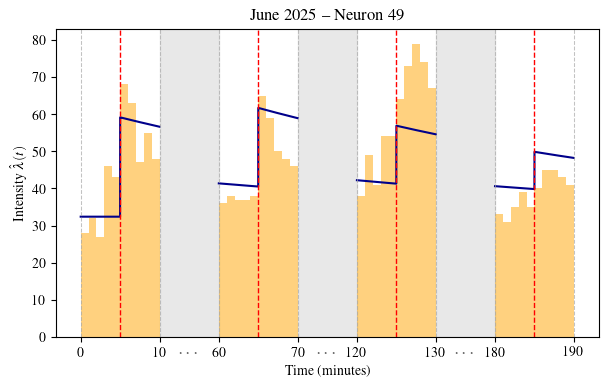

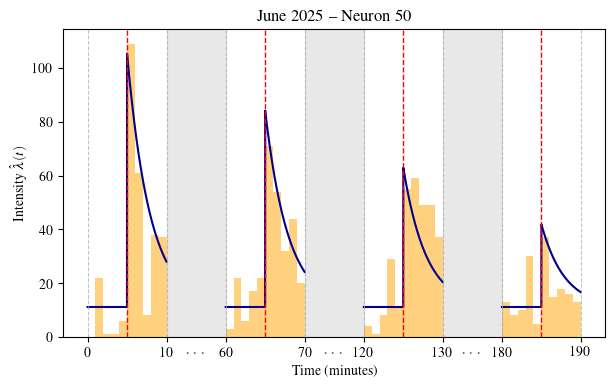

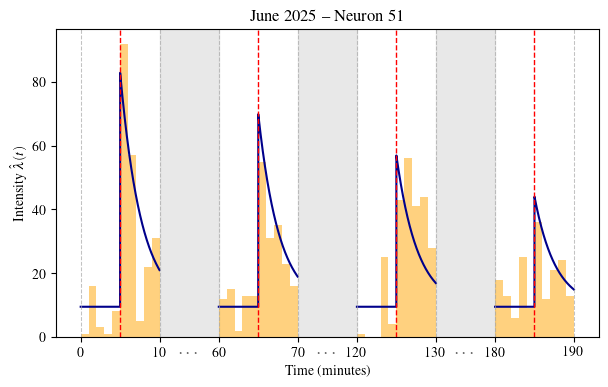

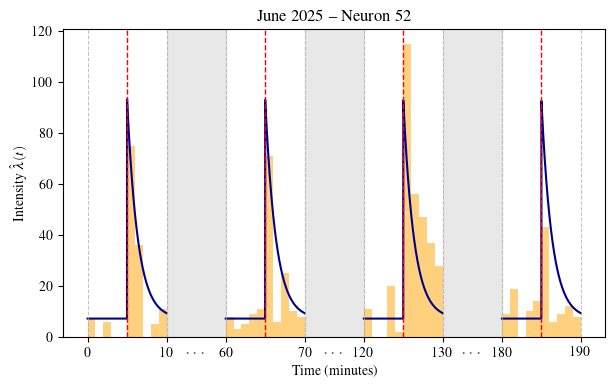

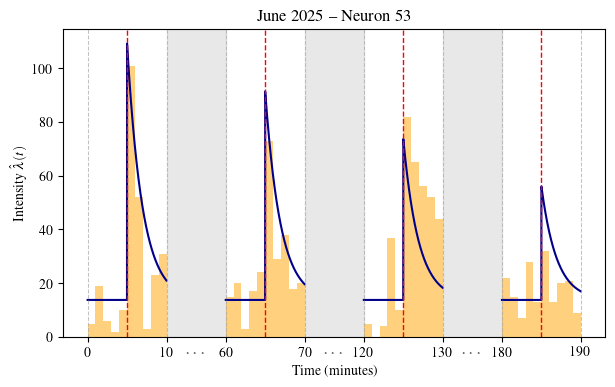

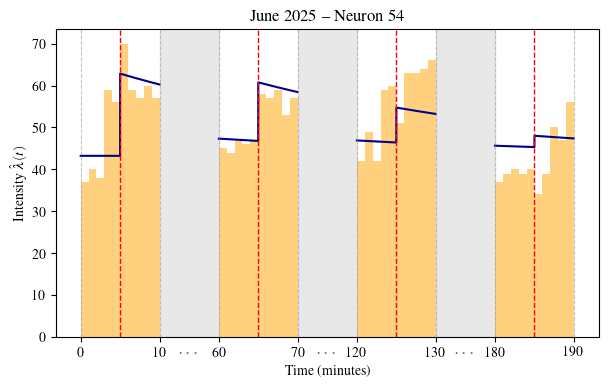

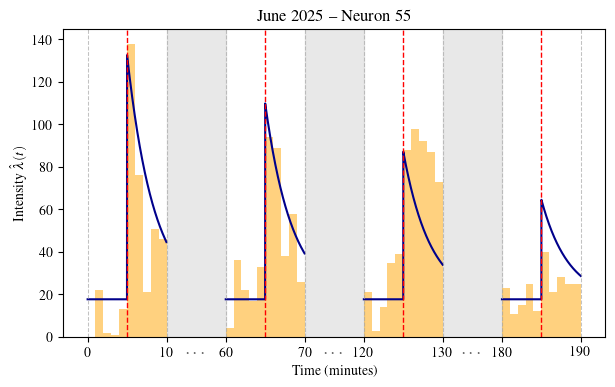

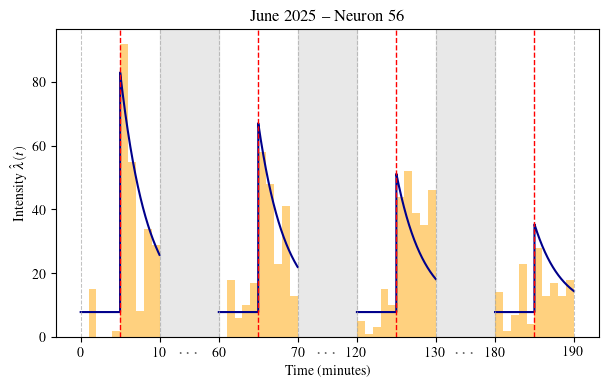

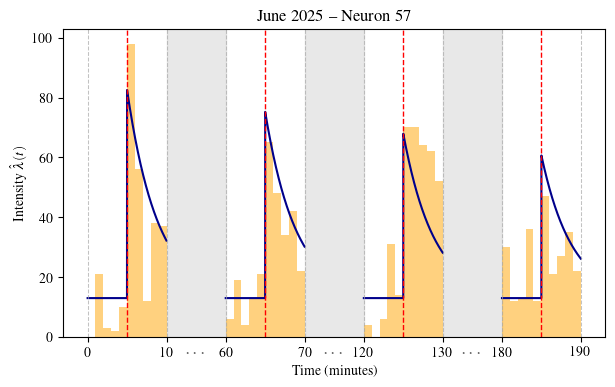

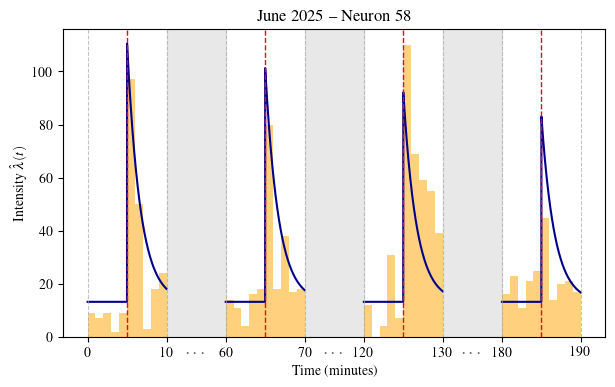

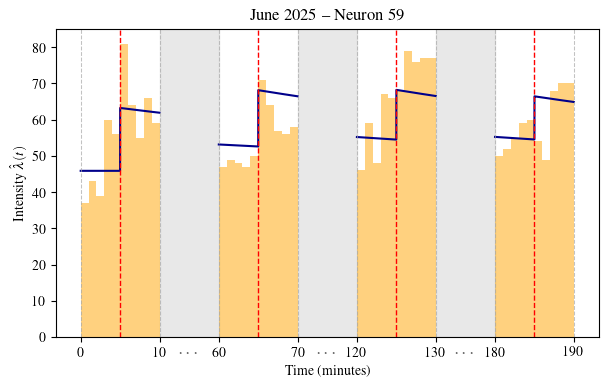

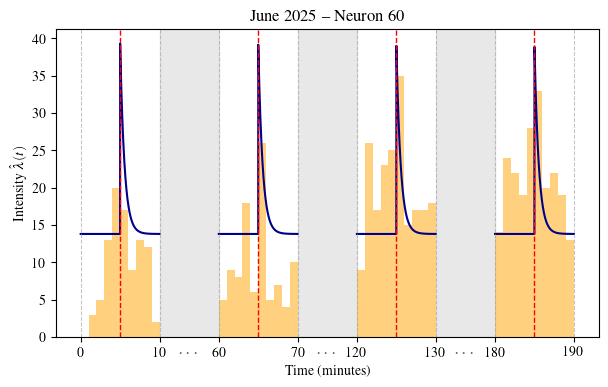

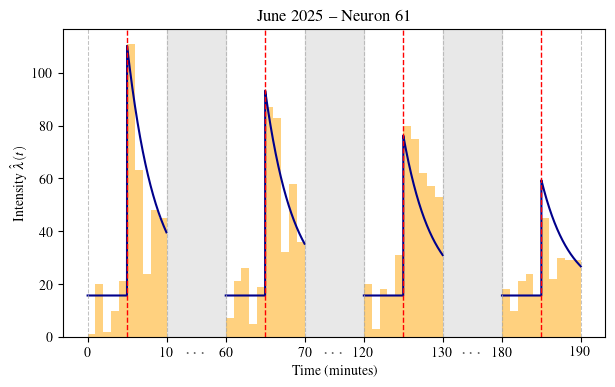

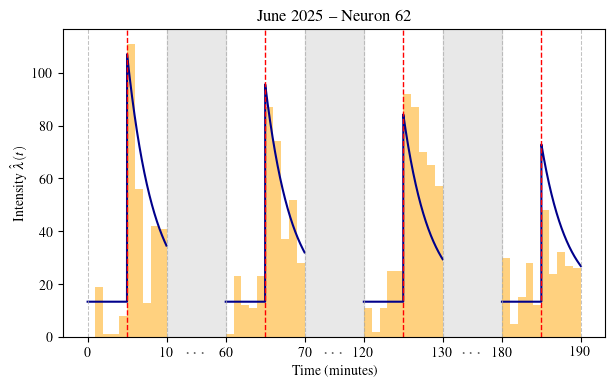

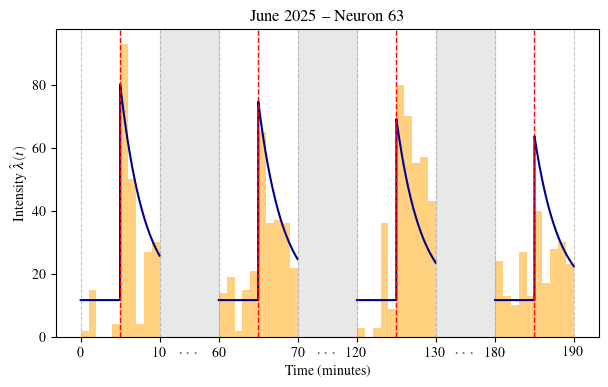

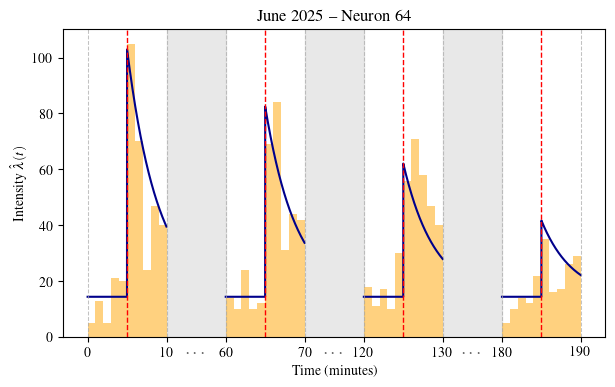

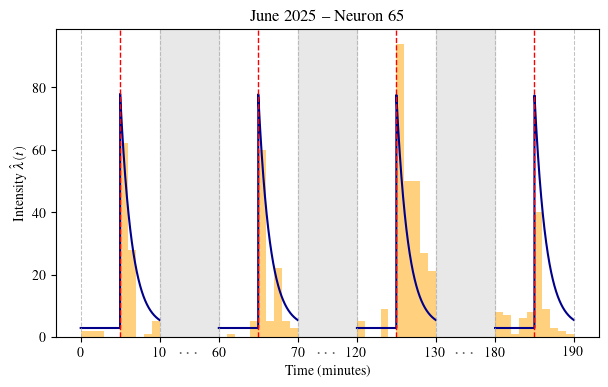

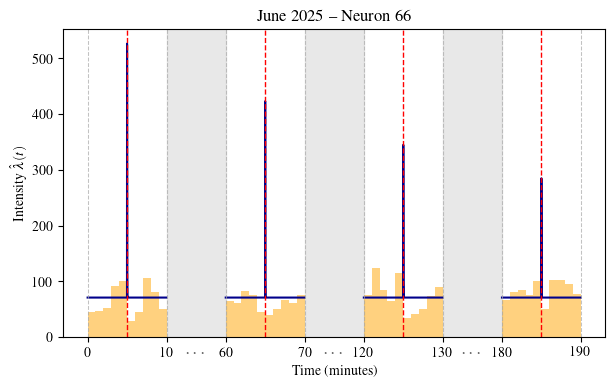

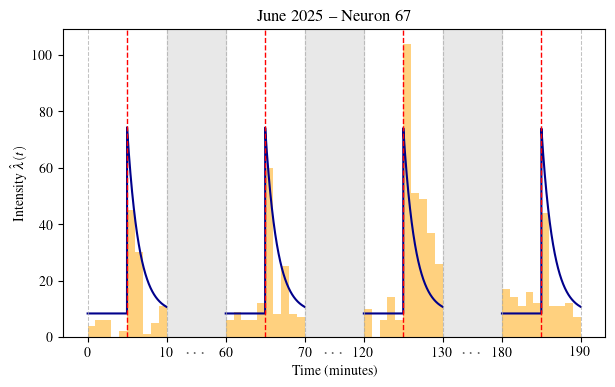

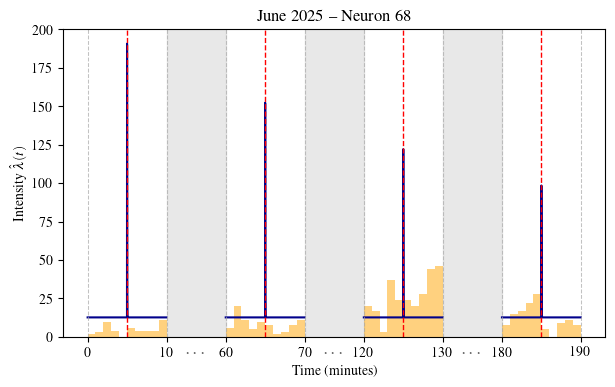

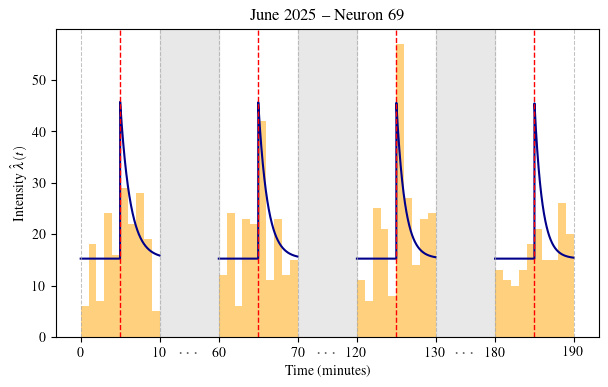

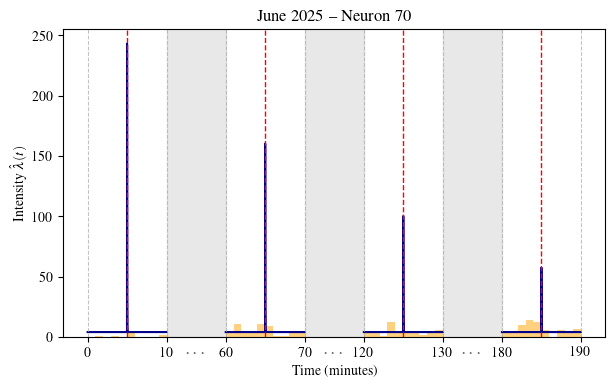

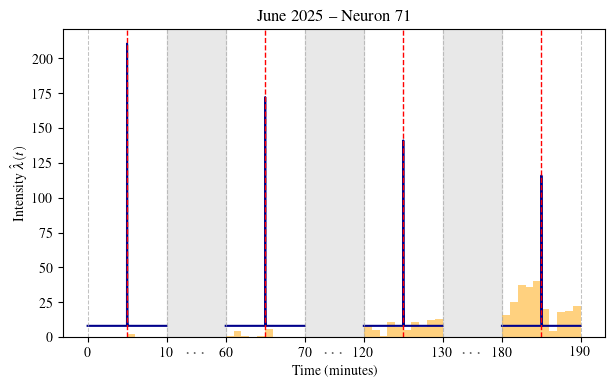

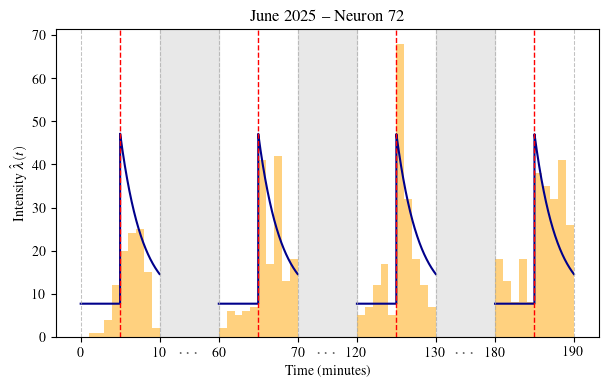

In [8]:
gap = 42.5  # minutes to shift each interval for plotting

init_params1 = [np.log(10), np.log(10), np.log(7.5), np.log(0.01), np.log(1.0), np.log(0.1), np.log(0.05)] 
init_params2 = [np.log(5), np.log(10), np.log(0.5), np.log(0.1), np.log(1.0), np.log(0.1), np.log(0.01)]
init_params3 = [np.log(10), np.log(50), np.log(7.5), np.log(0.01), np.log(1.0), np.log(0.1), np.log(0.05)]

for i in range(len(peak_times)):
    pp1 = hep.fit_process(init_params1, peak_times[i], stimuli, T, weights=None, observation_intervals=observation_intervals, sum_values=False,
                            add_delay=False, fixed_jumps=False, fixed_decay=False, fixed_delay=False, inhibitory_decay=False, inhibitory_delay=False)
    pp2 = hep.fit_process(init_params2, peak_times[i], stimuli, T, weights=None, observation_intervals=observation_intervals, sum_values=False,
                            add_delay=False, fixed_jumps=False, fixed_decay=False, fixed_delay=False, inhibitory_decay=False, inhibitory_delay=False)
    pp3 = hep.fit_process(init_params3, peak_times[i], stimuli, T, weights=None, observation_intervals=observation_intervals, sum_values=False,
                            add_delay=False, fixed_jumps=False, fixed_decay=False, fixed_delay=False, inhibitory_decay=False, inhibitory_delay=False)
    ## Choose best fit among three initializations
    fits = [pp1, pp2, pp3]
    fits_ll = [fit.fun for fit in fits]
    best_fit_index = np.argmin(fits_ll)
    pp = fits[best_fit_index]
    
    curve = hep.calculate_intensity(params=pp.x, t=np.linspace(0, T, T*100), jumps=stimuli, 
                                    add_delay=False, fixed_jumps=False, fixed_decay=False, fixed_delay=False, inhibitory_decay=False, inhibitory_delay=False, log_params=True)
    
    ## Plot with gaps at non-observation intervals
    time_grid = np.linspace(0, T, T*100)

    fig, ax = plt.subplots(figsize=(7, 4))

    # Plot histogram and fitted curve for each observation interval
    for j, (start, end) in enumerate(observation_intervals):
        # Filter data for this interval
        mask_time = (time_grid >= start) & (time_grid <= end)
        mask_events = (np.array(peak_times[i]) >= start) & (np.array(peak_times[i]) <= end)
        
        # Plot fitted intensity
        ax.plot(time_grid[mask_time] - gap * j, curve[mask_time], color='darkblue', linewidth=1.5, zorder=2)
        
        # Plot histogram of observed events
        if np.sum(mask_events) > 0:
            ax.hist(np.array(peak_times[i])[mask_events] - gap * j, bins=np.arange(start, end + 1, 1) - gap * j,
                    density=False, alpha=0.5, color='orange', zorder=1)
    
    # Shade gap regions between observation intervals and add ... text
    for j in range(len(observation_intervals) - 1):
        gap_left  = observation_intervals[j][1] - gap * j
        gap_right = observation_intervals[j+1][0] - gap * (j + 1)
        ax.axvspan(gap_left, gap_right, color='lightgray', alpha=0.5, zorder=0)
        ax.text((gap_left + gap_right) / 2, ax.get_ylim()[1] * (-0.045), r'$\cdots$', 
                ha='center', va='center', fontsize=14, color='dimgray', transform=ax.transData)

    # Mark stimulus locations (only if within observation intervals)
    for stimulus in stimuli:
        for j, (start, end) in enumerate(observation_intervals):
            if start <= stimulus <= end:
                ax.axvline(x=stimulus - gap * j, color='r', linestyle='--', lw=1, zorder=2)
                break
    
    # Mark interval boundaries with dotted lines
    for j, (start, end) in enumerate(observation_intervals):
        ax.axvline(x=start - gap * j, color='darkgray', linestyle='--', lw=0.75, alpha=0.7)
        ax.axvline(x=end - gap * j, color='darkgray', linestyle='--', lw=0.75, alpha=0.7)
    
    ax.set_xlabel('Time (minutes)')
    ax.set_ylabel(r'Intensity $\hat{\lambda}(t)$')
    
    # Adjust x-axis labels: actual times at interval boundaries only
    xticks_pos = []
    xticks_lab = []
    for j, (start, end) in enumerate(observation_intervals):
        xticks_pos.extend([start - gap * j, end - gap * j])
        xticks_lab.extend([str(int(start)), str(int(end))])
    ax.set_xticks(xticks_pos)
    ax.set_xticklabels(xticks_lab)

    ax.set_title(f'June 2025 -- Neuron {i+1}')
    
    plt.savefig(f'../figures/Jun0425/Jun0425_neuron_{i+1}_fit.pdf', bbox_inches='tight')
    plt.show(block=False)
